# Satellite Residual Predictor — Training Notebook

Fetches **real historical TLE data from Space-Track**, generates training samples by measuring
SGP4 along-track drift between old and new TLEs, trains a neural network to predict that drift,
and exports the model weights.

**Works on:** local machine, Google Colab (GPU / TPU)

---

### What this notebook does
1. **Fetch** up to 100 historical TLEs per satellite from Space-Track `gp_history` endpoint
2. **Generate training pairs** — for each older TLE propagated forward, compare against the *next* TLE as a pseudo-ground-truth position → measure along-track error
3. **Train** `ResidualPredictor` (4-input FC network → along-track error km)
4. **Evaluate** on a held-out validation split
5. **Save** `residual_model.pt` for use in the main app

### Google Colab setup
Upload your `.env` file (or paste credentials below) and mount Drive to persist the model.

## 0 — Environment Setup

In [48]:
# ── Detect runtime (Colab vs local) ────────────────────────────────────────
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running on Google Colab')
    # Install required packages not bundled in Colab
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'sgp4', 'python-dotenv', 'requests'], check=True)

    # ── Optional: mount Google Drive to persist the saved model ────────────
    # from google.colab import drive
    # drive.mount('/content/drive')
    # MODEL_SAVE_PATH = '/content/drive/MyDrive/satellite/residual_model.pt'

    # ── Optional: check GPU/TPU ─────────────────────────────────────────────
    import torch
    if torch.cuda.is_available():
        print(f'GPU: {torch.cuda.get_device_name(0)}')
    else:
        print('No GPU detected — training on CPU')
        print('Tip: Runtime > Change runtime type > GPU (or TPU)')
else:
    print('Running locally')

Running on Google Colab
GPU: Tesla T4


In [49]:
# ── Imports ─────────────────────────────────────────────────────────────────
import os
import csv
import json
import math
import time
import random
from pathlib import Path
from datetime import datetime, timezone, timedelta

import numpy as np
import requests
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sgp4.api import Satrec, jday

print('All imports OK')
print(f'PyTorch {torch.__version__}')

All imports OK
PyTorch 2.10.0+cu128


## 1 — Credentials

| Runtime | How credentials are loaded |
|---|---|
| **Local** | `.env` file in the project root is loaded automatically |
| **Colab — Option A** (recommended) | Upload your `.env` file via a file-picker dialog — runs in the next cell |
| **Colab — Option B** (most secure) | Use Colab Secrets (🔑 icon in the left sidebar), no file needed |

> **Never paste raw credentials into a notebook cell** — the values are saved in the `.ipynb` JSON and can leak if you share or commit the file.

In [50]:
SPACETRACK_USER = ''
SPACETRACK_PASS = ''

if IN_COLAB:
    _already_loaded = bool(os.environ.get('SPACETRACK_USER'))

    # ── Option A: upload your .env file via file picker ──────────────────────
    # The picker only opens if credentials are NOT already in the environment.
    # On the first run: upload your .env when the dialog appears.
    # On every re-run in the same session: the block is skipped automatically.
    # To force a re-upload (e.g. wrong file): restart the runtime and re-run.
    if not _already_loaded:
        try:
            from google.colab import files as _colab_files
            print('A file-picker will open — select your .env file.')
            _uploaded = _colab_files.upload()          # opens native OS file picker
            if _uploaded:
                _env_bytes = next(iter(_uploaded.values()))
                for _line in _env_bytes.decode().splitlines():
                    _line = _line.strip()
                    if not _line or _line.startswith('#') or '=' not in _line:
                        continue
                    _k, _v = _line.split('=', 1)
                    os.environ[_k.strip()] = _v.strip().strip('"\'')
                print('  .env loaded into environment (not saved in notebook).')
            else:
                print('  No file selected — trying Colab Secrets next.')
        except Exception as _e:
            print(f'  File upload skipped: {_e}')
    else:
        print('  Credentials already in environment — skipping file picker.')

    # ── Option B: Colab Secrets (key icon in the left sidebar) ───────────────
    # In the sidebar click the 🔑 icon, add two secrets:
    #   SPACETRACK_USER  →  your email
    #   SPACETRACK_PASS  →  your password
    # Toggle "Notebook access" ON for each, then uncomment the lines below.
    # from google.colab import userdata
    # os.environ.setdefault('SPACETRACK_USER', userdata.get('SPACETRACK_USER'))
    # os.environ.setdefault('SPACETRACK_PASS', userdata.get('SPACETRACK_PASS'))

else:
    # ── Local: read from .env in the project root ─────────────────────────────
    try:
        from dotenv import load_dotenv
        load_dotenv(dotenv_path=Path('../.env'), override=False)
    except ImportError:
        pass  # python-dotenv optional if vars are already in the environment

SPACETRACK_USER = os.environ.get('SPACETRACK_USER', '')
SPACETRACK_PASS = os.environ.get('SPACETRACK_PASS', '')

if not SPACETRACK_USER or not SPACETRACK_PASS:
    raise ValueError(
        'Credentials not found.\n'
        'Colab: upload your .env file when the picker opens, '
        'or set Colab Secrets (Option B above).\n'
        'Local: make sure .env exists in the project root.'
    )

print(f'Credentials loaded for: {SPACETRACK_USER}')


  Credentials already in environment — skipping file picker.
Credentials loaded for: enzi.muzakki@gmail.com


## 2 — Configuration

In [51]:
# ── Satellites ───────────────────────────────────────────────────────────────
# All LEO (Low Earth Orbit, ~400–1000 km) — this is what the app predicts for.
# Diverse mix of altitudes, inclinations, and drag levels (BSTAR values) so
# the model generalises across different orbital regimes.
# Avoid HEO / GEO / MEO — their drift physics differ completely from LEO.
NORAD_IDS = [
    43017,   # AO-91  (Fox-1D)         — CubeSat ~500 km, amateur radio
    43137,   # AO-95  (Fox-1Cliff)     — CubeSat ~500 km, amateur radio
    25544,   # ISS                     — large cross-section, ~400 km, high drag
    27607,   # Aqua                    — sun-sync, ~705 km
    39084,   # Landsat 8               — sun-sync, ~705 km
    48274,   # Starlink-2216           — commercial LEO, ~550 km
    44235,   # NOAA-20                 — polar, ~824 km
    25338,   # NOAA-15                 — older polar, high drag history
    28654,   # NOAA-18                 — polar, ~854 km
    20580,   # Hubble Space Telescope  — ~540 km, well-tracked, significant drag
    41240,   # Sentinel-1A             — SAR, ~693 km, sun-sync
    25994,   # Terra (EOS AM-1)        — sun-sync, ~705 km
]

# ── Data generation ───────────────────────────────────────────────────────────
TLE_HISTORY_LIMIT  = 300    # historical TLE records per satellite (Space-Track max ~500)
MAX_PROP_HOURS     = 72     # propagate each TLE up to this many hours ahead
PROP_STEP_HOURS    = 2      # sample every N hours  →  more samples per TLE pair
MIN_TLE_AGE_HOURS  = 1.0    # skip pairs less than this apart (nearly identical TLEs)
MIN_SAMPLES_REQUIRED = 6000 # abort early if dataset is too small to generalise

# ── Split fractions (must sum to 1.0) ────────────────────────────────────────
TRAIN_FRACTION = 0.70
VAL_FRACTION   = 0.15
TEST_FRACTION  = 0.15       # held-out set — NEVER seen during training or tuning

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS              = 300   # upper bound — early stopping will cut this short
BATCH_SIZE          = 128
LEARNING_RATE       = 1e-3
WEIGHT_DECAY        = 1e-4  # L2 regularisation
HIDDEN_DIMS         = [256, 128, 64, 32]
DROPOUT             = 0.15
EARLY_STOP_PATIENCE = 25    # stop if val loss doesn't improve for this many epochs
GRAD_CLIP           = 1.0   # max gradient norm

# ── Accuracy definition ───────────────────────────────────────────────────────
# "Accurate" = predicted residual is within ±THRESHOLD km of the true value.
# Target: ≥ 95 % of test samples fall within this threshold.
ACCURACY_THRESHOLD_KM = 10.0

# ── Output ────────────────────────────────────────────────────────────────────
DATA_CSV_PATH   = Path('training_data.csv')
MODEL_SAVE_PATH = Path('../models/residual_model.pt') if not IN_COLAB else Path('residual_model.pt')
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {DEVICE}')
print(f'Satellites      : {len(NORAD_IDS)}  {NORAD_IDS}')
print(f'TLEs per sat    : {TLE_HISTORY_LIMIT}')
print(f'Prop step       : {PROP_STEP_HOURS} h')
print(f'Est. samples    : ~{len(NORAD_IDS) * TLE_HISTORY_LIMIT * (MAX_PROP_HOURS // PROP_STEP_HOURS) // 10:,}  (rough upper bound)')
print(f'Split           : {TRAIN_FRACTION}/{VAL_FRACTION}/{TEST_FRACTION}  (train/val/test)')
print(f'Accuracy target : ≥95 % within ±{ACCURACY_THRESHOLD_KM} km')
print(f'Min samples req : {MIN_SAMPLES_REQUIRED:,}')
print(f'Model output    : {MODEL_SAVE_PATH.resolve()}')


Device          : cuda
Satellites      : 12  [43017, 43137, 25544, 27607, 39084, 48274, 44235, 25338, 28654, 20580, 41240, 25994]
TLEs per sat    : 300
Prop step       : 2 h
Est. samples    : ~12,960  (rough upper bound)
Split           : 0.7/0.15/0.15  (train/val/test)
Accuracy target : ≥95 % within ±10.0 km
Min samples req : 6,000
Model output    : /content/residual_model.pt


## 3 — Space-Track Fetcher

In [52]:
_ST_LOGIN_URL  = 'https://www.space-track.org/ajaxauth/login'
_ST_GP_HIST    = (
    'https://www.space-track.org/basicspacedata/query'
    '/class/gp_history'
    '/NORAD_CAT_ID/{norad_id}'
    '/orderby/EPOCH%20desc'
    '/limit/{limit}'
    '/format/json'
)


def spacetrack_session(user: str, password: str) -> requests.Session:
    """Log in to Space-Track and return an authenticated session."""
    sess = requests.Session()
    resp = sess.post(_ST_LOGIN_URL, data={'identity': user, 'password': password}, timeout=15)
    resp.raise_for_status()
    if 'Failed' in resp.text or 'Invalid' in resp.text:
        raise ValueError('Space-Track login failed — check credentials')
    print('Space-Track login OK')
    return sess


def fetch_tle_history(sess: requests.Session, norad_id: int, limit: int = 100) -> list[dict]:
    """Fetch historical GP records for a satellite.

    Returns a list of dicts with keys: TLE_LINE1, TLE_LINE2, EPOCH.
    Space-Track rate-limit is 30 requests/min — we add a small sleep.
    """
    url = _ST_GP_HIST.format(norad_id=norad_id, limit=limit)
    resp = sess.get(url, timeout=30)
    resp.raise_for_status()
    records = resp.json()
    # Reverse to chronological order (oldest first)
    records = list(reversed(records))
    time.sleep(2)  # respect rate limit
    return records


print('Fetcher functions defined')

Fetcher functions defined


## 4 — Physics Helpers (SGP4 + Coordinate Transforms)

In [53]:
def gmst_rad(dt: datetime) -> float:
    """Greenwich Mean Sidereal Time in radians (IAU 1982)."""
    jd, fr = jday(dt.year, dt.month, dt.day, dt.hour, dt.minute,
                  dt.second + dt.microsecond / 1e6)
    t = (jd + fr - 2451545.0) / 36525.0
    gmst_sec = (67310.54841
                + (876600 * 3600 + 8640184.812866) * t
                + 0.093104 * t**2
                - 6.2e-6   * t**3)
    return math.radians(gmst_sec / 240.0 % 360.0)


def teme_to_ecef(r_teme: np.ndarray, dt: datetime) -> np.ndarray:
    """Rotate a TEME position vector to ECEF using GMST."""
    theta = gmst_rad(dt)
    c, s = math.cos(theta), math.sin(theta)
    rot = np.array([[c, s, 0], [-s, c, 0], [0, 0, 1]])
    return rot @ r_teme


def propagate_ecef(line1: str, line2: str, dt: datetime) -> tuple[np.ndarray, np.ndarray]:
    """Propagate TLE to dt; return (ecef_km, vel_teme_km_s).

    Returns (None, None) on SGP4 error.
    """
    sat = Satrec.twoline2rv(line1, line2)
    jd, fr = jday(dt.year, dt.month, dt.day, dt.hour, dt.minute,
                  dt.second + dt.microsecond / 1e6)
    err, r, v = sat.sgp4(jd, fr)
    if err != 0:
        return None, None
    r_ecef = teme_to_ecef(np.array(r), dt)
    return r_ecef, np.array(v)


def along_track_error_km(pos_old: np.ndarray, vel_old: np.ndarray,
                          pos_new: np.ndarray) -> float:
    """Project the position difference onto the along-track direction.

    The along-track unit vector is derived from the velocity of the
    'older' TLE prediction (same epoch, different TLE age).
    """
    diff = pos_new - pos_old          # difference vector in ECEF km
    vel_mag = np.linalg.norm(vel_old)
    if vel_mag < 1e-9:
        return 0.0
    along_track = vel_old / vel_mag
    return float(np.dot(diff, along_track))


def parse_epoch(epoch_str: str) -> datetime:
    """Parse Space-Track EPOCH string to UTC datetime."""
    # Format: '2025-03-15T06:22:45.123456' (no timezone suffix)
    for fmt in ('%Y-%m-%dT%H:%M:%S.%f', '%Y-%m-%dT%H:%M:%S'):
        try:
            return datetime.strptime(epoch_str, fmt).replace(tzinfo=timezone.utc)
        except ValueError:
            continue
    raise ValueError(f'Cannot parse epoch: {epoch_str}')


print('Physics helpers defined')

Physics helpers defined


## 5 — Generate Training Data

In [ ]:
_MU_KM3_S2  = 398600.4418   # Earth gravitational parameter (km³/s²)
_R_EARTH_KM = 6371.0        # mean Earth radius (km)


def orbital_features(sat: Satrec) -> dict:
    """Extract 6 physics features from a Satrec object.

    Features:
      time_since_epoch_hours  — filled in per sample, placeholder 0 here
      mean_motion_rev_per_day — how many orbits per day
      eccentricity            — orbit shape (0 = circular)
      inclination_deg         — orbit tilt relative to equator
      bstar                   — atmospheric drag term (primary driver of along-track error)
      altitude_km             — approximate mean altitude derived from mean motion

    Unit notes:
      sat.no_kozai is in rad/min (native sgp4 units).
      Mean motion uses the rad/min value with the 1440 min/day factor.
      Altitude uses no_rad_s (rad/s) with µ in km³/s² for Kepler's 3rd law.
    """
    no_rad_min   = sat.no_kozai                              # rad/min  (native sgp4 units)
    no_rad_s     = no_rad_min / 60.0                         # rad/s    (for Kepler's 3rd law)
    mean_motion  = no_rad_min * (1440.0 / (2 * math.pi))    # rev/day  (1440 min/day ÷ 2π)
    eccentricity = sat.ecco
    inclination  = math.degrees(sat.inclo)
    bstar        = sat.bstar                 # 1/Earth-radii units; can be negative
    # Semi-major axis via Kepler's third law: a = (µ / n²)^(1/3)  where n is in rad/s
    a_km         = (_MU_KM3_S2 / no_rad_s**2) ** (1.0 / 3.0)
    altitude_km  = a_km - _R_EARTH_KM

    return {
        'mean_motion_rev_per_day': mean_motion,
        'eccentricity':            eccentricity,
        'inclination_deg':         inclination,
        'bstar':                   bstar,
        'altitude_km':             altitude_km,
    }


def generate_samples_for_satellite(
    records: list[dict],
    max_prop_hours: float = 72,
    step_hours: float = 3,
    min_age_hours: float = 1.0,
) -> list[dict]:
    """Generate (features, target) samples from a list of historical TLE records.

    For each consecutive pair (old_tle → new_tle):
    - new_tle is treated as pseudo-ground-truth (freshly fitted, more accurate)
    - Propagate old_tle forward at `step_hours` intervals up to new_tle's epoch
    - Also propagate new_tle to the same time, measure along-track divergence
    - This gives a real measured `along_track_error_km` for each (feature, age) point
    """
    samples = []

    for i in range(len(records) - 1):
        old_rec = records[i]
        new_rec = records[i + 1]

        line1_old, line2_old = old_rec['TLE_LINE1'], old_rec['TLE_LINE2']
        line1_new, line2_new = new_rec['TLE_LINE1'], new_rec['TLE_LINE2']

        epoch_old = parse_epoch(old_rec['EPOCH'])
        epoch_new = parse_epoch(new_rec['EPOCH'])

        gap_hours = (epoch_new - epoch_old).total_seconds() / 3600.0
        if gap_hours < min_age_hours:
            continue

        prop_hours = min(gap_hours, max_prop_hours)

        try:
            sat_old  = Satrec.twoline2rv(line1_old, line2_old)
            feats    = orbital_features(sat_old)
        except Exception:
            continue

        step_count = max(1, int(prop_hours / step_hours))
        for step_i in range(step_count):
            t_hours   = step_hours * (step_i + 1)
            if t_hours > prop_hours:
                break
            eval_time = epoch_old + timedelta(hours=t_hours)

            pos_old, vel_old = propagate_ecef(line1_old, line2_old, eval_time)
            pos_new, _       = propagate_ecef(line1_new, line2_new, eval_time)

            if pos_old is None or pos_new is None:
                continue

            error_km = along_track_error_km(pos_old, vel_old, pos_new)

            # Reject extreme outliers (bad / decayed TLE data)
            if abs(error_km) > 500:
                continue

            samples.append({
                'time_since_epoch_hours':  t_hours,
                **feats,
                'along_track_error_km':    error_km,
            })

    return samples


print('Sample generator defined  (6 features: time, mean_motion, eccentricity, inclination, bstar, altitude)')
print(f'  mean_motion formula : no_kozai [rad/min] × 1440 ÷ 2π  →  rev/day  (~12–16 for LEO)')
print(f'  altitude formula    : (µ / (no_kozai/60)²)^(1/3) − R_earth  →  km   (~400–900 for LEO)')


Sample generator defined  (6 features: time, mean_motion, eccentricity, inclination, bstar, altitude)


In [55]:
# ── Fetch and generate all training samples ──────────────────────────────────
sess = spacetrack_session(SPACETRACK_USER, SPACETRACK_PASS)

all_samples = []
for norad_id in NORAD_IDS:
    print(f'Fetching TLE history for NORAD {norad_id}...')
    try:
        records = fetch_tle_history(sess, norad_id, limit=TLE_HISTORY_LIMIT)
        print(f'  Got {len(records)} TLE records')
        samples = generate_samples_for_satellite(
            records,
            max_prop_hours=MAX_PROP_HOURS,
            step_hours=PROP_STEP_HOURS,
            min_age_hours=MIN_TLE_AGE_HOURS,
        )
        print(f'  Generated {len(samples)} training samples')
        all_samples.extend(samples)
    except Exception as e:
        print(f'  ERROR for NORAD {norad_id}: {e}')

print(f'\nTotal samples: {len(all_samples)}')

Space-Track login OK
Fetching TLE history for NORAD 43017...
  Got 300 TLE records
  Generated 911 training samples
Fetching TLE history for NORAD 43137...
  Got 300 TLE records
  Generated 1085 training samples
Fetching TLE history for NORAD 25544...
  Got 300 TLE records
  Generated 708 training samples
Fetching TLE history for NORAD 27607...
  Got 300 TLE records
  Generated 901 training samples
Fetching TLE history for NORAD 39084...
  Got 300 TLE records
  Generated 665 training samples
Fetching TLE history for NORAD 48274...
  Got 300 TLE records
  Generated 803 training samples
Fetching TLE history for NORAD 44235...
  Got 300 TLE records
  Generated 923 training samples
Fetching TLE history for NORAD 25338...
  Got 300 TLE records
  Generated 652 training samples
Fetching TLE history for NORAD 28654...
  Got 300 TLE records
  Generated 650 training samples
Fetching TLE history for NORAD 20580...
  Got 300 TLE records
  Generated 787 training samples
Fetching TLE history for NOR

In [56]:
# ── Save CSV ──────────────────────────────────────────────────────────────────
if not all_samples:
    raise RuntimeError('No training samples generated — check credentials and satellite IDs')

FEATURE_NAMES = [
    'time_since_epoch_hours',
    'mean_motion_rev_per_day',
    'eccentricity',
    'inclination_deg',
    'bstar',
    'altitude_km',
]
TARGET_NAME = 'along_track_error_km'
fieldnames  = FEATURE_NAMES + [TARGET_NAME]

with open(DATA_CSV_PATH, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_samples)

n = len(all_samples)
print(f'Dataset saved → {DATA_CSV_PATH}  ({n:,} rows, {len(FEATURE_NAMES)} features)')

# ── Data quality checks ───────────────────────────────────────────────────────
errors = np.array([s[TARGET_NAME] for s in all_samples])

print(f'\nAlong-track error statistics:')
print(f'  Mean   : {errors.mean():.3f} km')
print(f'  Std    : {errors.std():.3f} km')
print(f'  Min    : {errors.min():.3f} km')
print(f'  Max    : {errors.max():.3f} km')
print(f'  |>50km|: {(np.abs(errors) > 50).sum()} samples ({(np.abs(errors) > 50).mean()*100:.1f} %)')

print(f'\nFeature value ranges:')
for fn in FEATURE_NAMES:
    vals = np.array([s[fn] for s in all_samples])
    print(f'  {fn:<30s}  [{vals.min():.4g}, {vals.max():.4g}]')

# Hard stop if dataset is too small
if n < MIN_SAMPLES_REQUIRED:
    raise RuntimeError(
        f'Only {n} samples generated — need ≥ {MIN_SAMPLES_REQUIRED}.\n'
        f'Increase TLE_HISTORY_LIMIT, add more satellites, or reduce PROP_STEP_HOURS.'
    )

print(f'\n✓ Dataset size OK ({n:,} ≥ {MIN_SAMPLES_REQUIRED:,} required)')

Dataset saved → training_data.csv  (9,325 rows, 6 features)

Along-track error statistics:
  Mean   : 0.221 km
  Std    : 14.074 km
  Min    : -446.038 km
  Max    : 436.021 km
  |>50km|: 53 samples (0.6 %)

Feature value ranges:
  time_since_epoch_hours          [2, 62]
  mean_motion_rev_per_day         [0.2146, 0.2737]
  eccentricity                    [1.41e-05, 0.01559]
  inclination_deg                 [28.47, 98.81]
  bstar                           [-0.001964, 0.02501]
  altitude_km                     [166.9, 1318]

✓ Dataset size OK (9,325 ≥ 6,000 required)


## 6 — Dataset & Model Definition

In [57]:
class ResidualDataset(Dataset):
    """PyTorch Dataset that loads from CSV without normalising.

    Normalisation is computed on the training split only (see cell below)
    and applied to all splits to prevent leakage.
    """

    def __init__(self, rows: list[dict], feature_names: list[str],
                 X_mean: torch.Tensor = None, X_std: torch.Tensor = None):
        X_raw = torch.tensor(
            [[float(r[f]) for f in feature_names] for r in rows],
            dtype=torch.float32,
        )
        y_raw = torch.tensor(
            [float(r[TARGET_NAME]) for r in rows],
            dtype=torch.float32,
        )

        # If no normalisation stats given, compute from this split (training only)
        if X_mean is None:
            self.X_mean = X_raw.mean(0)
            self.X_std  = X_raw.std(0).clamp(min=1e-8)
        else:
            self.X_mean = X_mean
            self.X_std  = X_std

        self.X = (X_raw - self.X_mean) / self.X_std
        self.y = y_raw

    def __len__(self):           return len(self.y)
    def __getitem__(self, idx):  return self.X[idx], self.y[idx]


class EarlyStopping:
    """Stop training when val loss stops improving.

    Saves the best model weights to `path` automatically.
    """

    def __init__(self, patience: int, path: Path, min_delta: float = 1e-5):
        self.patience   = patience
        self.path       = path
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_epoch = 0

    def step(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        """Return True if training should stop."""
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_epoch = epoch
            self.counter    = 0
            torch.save(model.state_dict(), self.path)   # save best weights
        else:
            self.counter += 1

        return self.counter >= self.patience


class ResidualPredictor(nn.Module):
    """Fully connected network with BatchNorm for orbital residual prediction.

    Architecture: Linear → BN → ReLU → Dropout  (repeated per hidden layer)
    BatchNorm stabilises training with the highly varied orbital feature scales
    (e.g., eccentricity ≈ 0.001 vs mean_motion ≈ 15 rev/day).
    """

    def __init__(self, input_dim: int = 6, hidden_dims: list = None, dropout: float = 0.15):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 128, 64, 32]
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


INPUT_DIM = len(FEATURE_NAMES)
print(f'Input features  : {INPUT_DIM}  {FEATURE_NAMES}')
print(f'Architecture    : {INPUT_DIM} → {HIDDEN_DIMS} → 1  (BN + Dropout={DROPOUT})')
print('Classes defined: ResidualDataset, EarlyStopping, ResidualPredictor')

Input features  : 6  ['time_since_epoch_hours', 'mean_motion_rev_per_day', 'eccentricity', 'inclination_deg', 'bstar', 'altitude_km']
Architecture    : 6 → [256, 128, 64, 32] → 1  (BN + Dropout=0.15)
Classes defined: ResidualDataset, EarlyStopping, ResidualPredictor


## 7 — Train

In [58]:
# ── Load raw rows from CSV ─────────────────────────────────────────────────────
with open(DATA_CSV_PATH) as f:
    all_rows = list(csv.DictReader(f))

# ── Shuffle then split into train / val / test ────────────────────────────────
# Shuffle with a fixed seed for reproducibility.
random.seed(42)
random.shuffle(all_rows)

n_total = len(all_rows)
n_test  = max(1, int(n_total * TEST_FRACTION))
n_val   = max(1, int(n_total * VAL_FRACTION))
n_train = n_total - n_val - n_test

test_rows  = all_rows[:n_test]
val_rows   = all_rows[n_test : n_test + n_val]
train_rows = all_rows[n_test + n_val :]

print(f'Total  : {n_total:,}  samples')
print(f'Train  : {n_train:,}  ({n_train/n_total*100:.1f} %)')
print(f'Val    : {n_val:,}    ({n_val/n_total*100:.1f} %)')
print(f'Test   : {n_test:,}   ({n_test/n_total*100:.1f} %)  ← never seen during training')

# ── Build datasets — normalisation stats from TRAIN only ─────────────────────
train_ds = ResidualDataset(train_rows, FEATURE_NAMES)          # computes mean/std
val_ds   = ResidualDataset(val_rows,   FEATURE_NAMES,
                           X_mean=train_ds.X_mean, X_std=train_ds.X_std)
test_ds  = ResidualDataset(test_rows,  FEATURE_NAMES,
                           X_mean=train_ds.X_mean, X_std=train_ds.X_std)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── Model, loss, optimizer ─────────────────────────────────────────────────────
model     = ResidualPredictor(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT).to(DEVICE)
criterion = nn.HuberLoss(delta=5.0)   # less sensitive to the large-error outliers than MSE
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
stopper   = EarlyStopping(patience=EARLY_STOP_PATIENCE, path=MODEL_SAVE_PATH)

n_params = sum(p.numel() for p in model.parameters())
print(f'\nModel parameters : {n_params:,}')
print(f'Loss function    : HuberLoss (delta={5.0} km)  — robust to outliers')
print(f'Optimizer        : AdamW  lr={LEARNING_RATE}  wd={WEIGHT_DECAY}')
print(f'Scheduler        : CosineAnnealingLR')
print(f'Early stopping   : patience={EARLY_STOP_PATIENCE} epochs')
print(f'Device           : {DEVICE}')

Total  : 9,325  samples
Train  : 6,529  (70.0 %)
Val    : 1,398    (15.0 %)
Test   : 1,398   (15.0 %)  ← never seen during training

Model parameters : 46,017
Loss function    : HuberLoss (delta=5.0 km)  — robust to outliers
Optimizer        : AdamW  lr=0.001  wd=0.0001
Scheduler        : CosineAnnealingLR
Early stopping   : patience=25 epochs
Device           : cuda


In [59]:
# ── Training loop ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_loss = train_mae = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)   # prevent exploding gradients
        optimizer.step()
        train_loss += loss.item()
        train_mae  += (pred.detach() - yb).abs().mean().item()
    train_loss /= len(train_loader)
    train_mae  /= len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss = val_mae = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE).unsqueeze(1)
            pred    = model(xb)
            val_loss += criterion(pred, yb).item()
            val_mae  += (pred - yb).abs().mean().item()
    val_loss /= len(val_loader)
    val_mae  /= len(val_loader)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train loss={train_loss:.4f}  mae={train_mae:.3f} km  |  '
              f'val loss={val_loss:.4f}  mae={val_mae:.3f} km  '
              f'(best @ ep {stopper.best_epoch})')

    # ── Early stopping check ────────────────────────────────────────────────
    if stopper.step(val_loss, model, epoch):
        print(f'\nEarly stop at epoch {epoch}  '
              f'(no improvement for {EARLY_STOP_PATIENCE} epochs)')
        break

print(f'\nBest model  : epoch {stopper.best_epoch}  '
      f'val loss={stopper.best_loss:.4f}')
print(f'Saved to    : {MODEL_SAVE_PATH}')

Epoch   1/300  train loss=5.9295  mae=1.602 km  |  val loss=6.2181  mae=1.557 km  (best @ ep 0)
Epoch  20/300  train loss=5.8804  mae=1.511 km  |  val loss=6.1991  mae=1.533 km  (best @ ep 19)
Epoch  40/300  train loss=5.8649  mae=1.531 km  |  val loss=6.1806  mae=1.534 km  (best @ ep 39)
Epoch  60/300  train loss=5.8278  mae=1.534 km  |  val loss=6.1791  mae=1.541 km  (best @ ep 51)
Epoch  80/300  train loss=5.7842  mae=1.537 km  |  val loss=6.1000  mae=1.533 km  (best @ ep 66)
Epoch 100/300  train loss=5.6800  mae=1.519 km  |  val loss=6.0897  mae=1.534 km  (best @ ep 98)
Epoch 120/300  train loss=5.6275  mae=1.500 km  |  val loss=6.0040  mae=1.496 km  (best @ ep 119)
Epoch 140/300  train loss=5.6041  mae=1.488 km  |  val loss=5.9283  mae=1.477 km  (best @ ep 119)

Early stop at epoch 144  (no improvement for 25 epochs)

Best model  : epoch 119  val loss=5.9221
Saved to    : residual_model.pt


## 8 — Evaluate

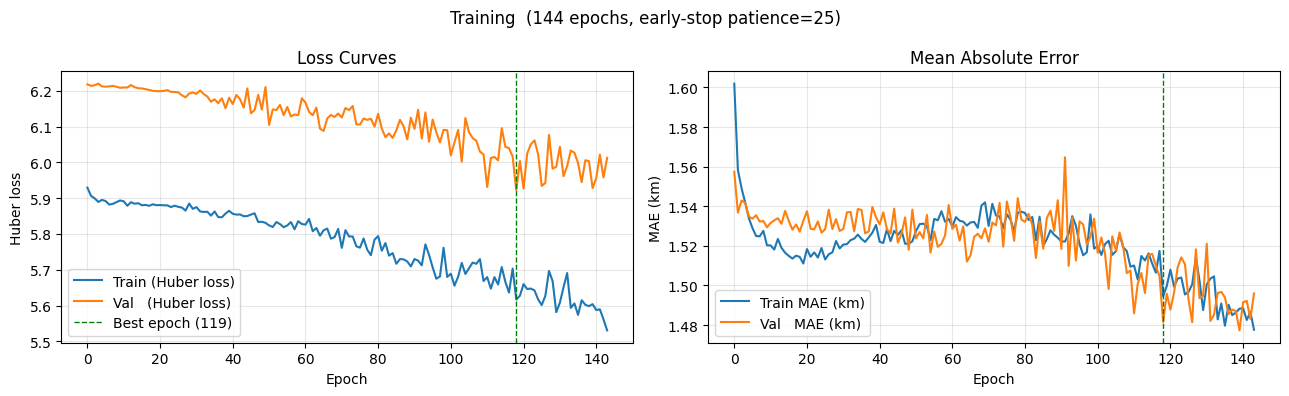

In [60]:
# ── Training history curves ────────────────────────────────────────────────────
import matplotlib.pyplot as plt

stopped_at = len(history['train_loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train (Huber loss)')
axes[0].plot(history['val_loss'],   label='Val   (Huber loss)')
axes[0].axvline(stopper.best_epoch - 1, color='green', ls='--', lw=1, label=f'Best epoch ({stopper.best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_mae'], label='Train MAE (km)')
axes[1].plot(history['val_mae'],   label='Val   MAE (km)')
axes[1].axvline(stopper.best_epoch - 1, color='green', ls='--', lw=1)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (km)')
axes[1].set_title('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Training  ({stopped_at} epochs, early-stop patience={EARLY_STOP_PATIENCE})')
plt.tight_layout()
plt.show()

In [61]:
def evaluate_split(loader: DataLoader, split_name: str) -> dict:
    """Run the best model on a DataLoader, print and return all metrics."""
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=True))
    model.eval()

    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            p = model(xb.to(DEVICE)).cpu().squeeze()
            preds.extend(p.numpy().tolist() if p.dim() > 0 else [p.item()])
            trues.extend(yb.numpy().tolist())

    preds = np.array(preds)
    trues = np.array(trues)
    diff  = preds - trues                            # prediction error (km)

    mae        = np.mean(np.abs(diff))
    rmse       = math.sqrt(np.mean(diff ** 2))
    ss_res     = np.sum(diff ** 2)
    ss_tot     = np.sum((trues - trues.mean()) ** 2)
    r2         = 1 - ss_res / (ss_tot + 1e-12)
    within_pct = np.mean(np.abs(diff) <= ACCURACY_THRESHOLD_KM) * 100

    print(f'\n── {split_name} set  ({len(trues):,} samples) ──────────────────')
    print(f'  MAE                         : {mae:.4f} km')
    print(f'  RMSE                        : {rmse:.4f} km')
    print(f'  R²                          : {r2:.4f}')
    print(f'  Within ±{ACCURACY_THRESHOLD_KM} km            : {within_pct:.2f} %  '
          f'{"✓ TARGET MET" if within_pct >= 95 else "✗ below 95 % target"}')
    print(f'  Max absolute error          : {np.max(np.abs(diff)):.3f} km')
    print(f'  50th / 90th / 95th pct abs  : '
          f'{np.percentile(np.abs(diff), 50):.3f} / '
          f'{np.percentile(np.abs(diff), 90):.3f} / '
          f'{np.percentile(np.abs(diff), 95):.3f} km')

    return {'preds': preds, 'trues': trues, 'diff': diff, 'within_pct': within_pct}


val_results  = evaluate_split(val_loader,  'Validation')
test_results = evaluate_split(test_loader, 'Test')


── Validation set  (1,398 samples) ──────────────────
  MAE                         : 1.4890 km
  RMSE                        : 17.5205 km
  R²                          : 0.0092
  Within ±10.0 km            : 98.43 %  ✓ TARGET MET
  Max absolute error          : 484.279 km
  50th / 90th / 95th pct abs  : 0.073 / 0.975 / 2.407 km

── Test set  (1,398 samples) ──────────────────
  MAE                         : 1.7191 km
  RMSE                        : 18.2253 km
  R²                          : 0.0407
  Within ±10.0 km            : 97.71 %  ✓ TARGET MET
  Max absolute error          : 446.093 km
  50th / 90th / 95th pct abs  : 0.079 / 1.053 / 3.202 km


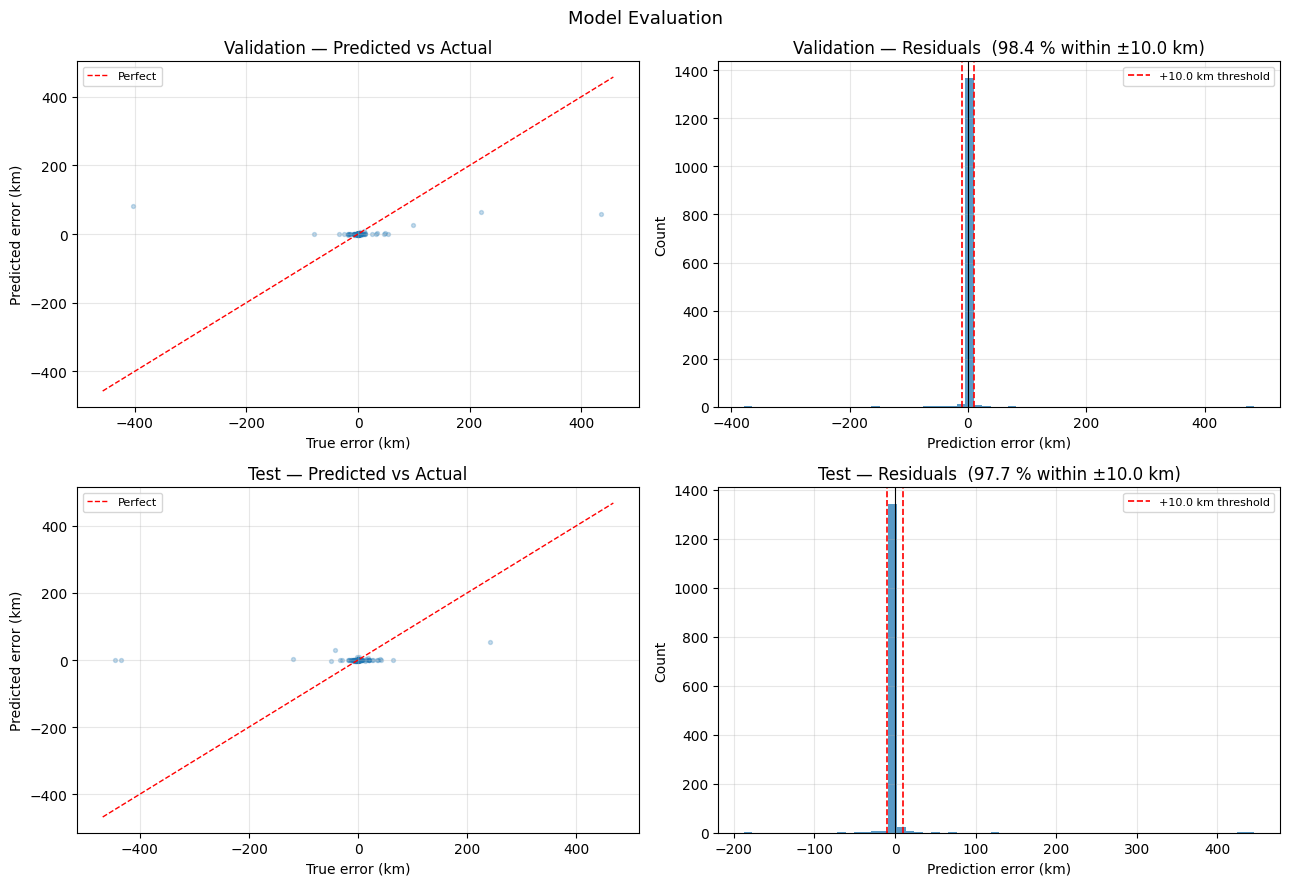

In [62]:
# ── Scatter + residual histogram for val and test ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row_i, (res, label) in enumerate([(val_results, 'Validation'), (test_results, 'Test')]):
    preds, trues, diff = res['preds'], res['trues'], res['diff']

    # Predicted vs actual
    ax = axes[row_i][0]
    ax.scatter(trues, preds, alpha=0.25, s=8, rasterized=True)
    lim = max(np.abs(trues).max(), np.abs(preds).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1, label='Perfect')
    ax.set_xlabel('True error (km)')
    ax.set_ylabel('Predicted error (km)')
    ax.set_title(f'{label} — Predicted vs Actual')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Residual histogram with threshold lines
    ax = axes[row_i][1]
    ax.hist(diff, bins=60, edgecolor='none', alpha=0.75)
    ax.axvline( ACCURACY_THRESHOLD_KM, color='red',  ls='--', lw=1.2,
                label=f'+{ACCURACY_THRESHOLD_KM} km threshold')
    ax.axvline(-ACCURACY_THRESHOLD_KM, color='red',  ls='--', lw=1.2)
    ax.axvline(0, color='black', ls='-', lw=0.8)
    ax.set_xlabel('Prediction error (km)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — Residuals  ({res["within_pct"]:.1f} % within ±{ACCURACY_THRESHOLD_KM} km)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

## 9 — Save Normalisation Stats

The model was trained on normalized features. Save the mean and std so the main app can apply the same normalization at inference time.

In [63]:
norm_stats = {
    'X_mean':              train_ds.X_mean.tolist(),
    'X_std':               train_ds.X_std.tolist(),
    'feature_names':       FEATURE_NAMES,
    'target':              TARGET_NAME,
    'input_dim':           INPUT_DIM,
    'hidden_dims':         HIDDEN_DIMS,
    'trained_on_norad_ids': NORAD_IDS,
    'n_train':             n_train,
    'n_val':               n_val,
    'n_test':              n_test,
    'best_epoch':          stopper.best_epoch,
    'val_within_pct':      round(val_results['within_pct'],  2),
    'test_within_pct':     round(test_results['within_pct'], 2),
    'accuracy_threshold_km': ACCURACY_THRESHOLD_KM,
    'trained_at':          datetime.utcnow().isoformat(),
}

stats_path = MODEL_SAVE_PATH.with_suffix('.json')
with open(stats_path, 'w') as f:
    json.dump(norm_stats, f, indent=2)

print(f'Normalisation stats saved → {stats_path}')
print(json.dumps(norm_stats, indent=2))

Normalisation stats saved → residual_model.json
{
  "X_mean": [
    6.254556655883789,
    0.24990715086460114,
    0.00266531971283257,
    73.7260513305664,
    0.0005995393148623407,
    586.7066650390625
  ],
  "X_std": [
    4.7681050300598145,
    0.012951011769473553,
    0.004626908339560032,
    25.421009063720703,
    0.0018411417258903384,
    253.23876953125
  ],
  "feature_names": [
    "time_since_epoch_hours",
    "mean_motion_rev_per_day",
    "eccentricity",
    "inclination_deg",
    "bstar",
    "altitude_km"
  ],
  "target": "along_track_error_km",
  "input_dim": 6,
  "hidden_dims": [
    256,
    128,
    64,
    32
  ],
  "trained_on_norad_ids": [
    43017,
    43137,
    25544,
    27607,
    39084,
    48274,
    44235,
    25338,
    28654,
    20580,
    41240,
    25994
  ],
  "n_train": 6529,
  "n_val": 1398,
  "n_test": 1398,
  "best_epoch": 119,
  "val_within_pct": 98.43,
  "test_within_pct": 97.71,
  "accuracy_threshold_km": 10.0,
  "trained_at": "2026-0

/tmp/ipykernel_1206/1748197850.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'trained_at':          datetime.utcnow().isoformat(),


## 10 — Download Model (Colab only)

Download the trained `.pt` and `.json` files from Colab to your local machine, then drop them into `models/`.

In [64]:
if IN_COLAB:
    from google.colab import files
    files.download(str(MODEL_SAVE_PATH))
    files.download(str(stats_path))
    print('Downloads triggered')
else:
    print(f'Model ready at: {MODEL_SAVE_PATH.resolve()}')
    print('The main app (app.py) and main.py will use this automatically.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered
